Efficientnet V2 - M

Phase 1

Model loaded successfully
Device       : cuda
Target layer : InvertedResidual

  Prediction Probabilities (Per-Class Thresholds)
  Atelectasis                44.71%  (threshold: 0.8)
  Cardiomegaly               93.55% <-- POSITIVE (threshold: 0.85)
  Consolidation              48.59%  (threshold: 0.8)
  Edema                      55.68%  (threshold: 0.85)
  Effusion                   90.02% <-- POSITIVE (threshold: 0.8)
  Emphysema                   8.31%  (threshold: 0.85)
  Fibrosis                   90.88% <-- POSITIVE (threshold: 0.85)
  Hernia                      6.31%  (threshold: 0.85)
  Infiltration               64.48% <-- POSITIVE (threshold: 0.6)
  Mass                       59.97%  (threshold: 0.8)
  No Finding                 12.26%  (threshold: 0.25)
  Nodule                     66.06%  (threshold: 0.8)
  Pleural_Thickening         93.12% <-- POSITIVE (threshold: 0.8)
  Pneumonia                  56.67%  (threshold: 0.85)
  Pneumothorax               42.49%  (threshold:

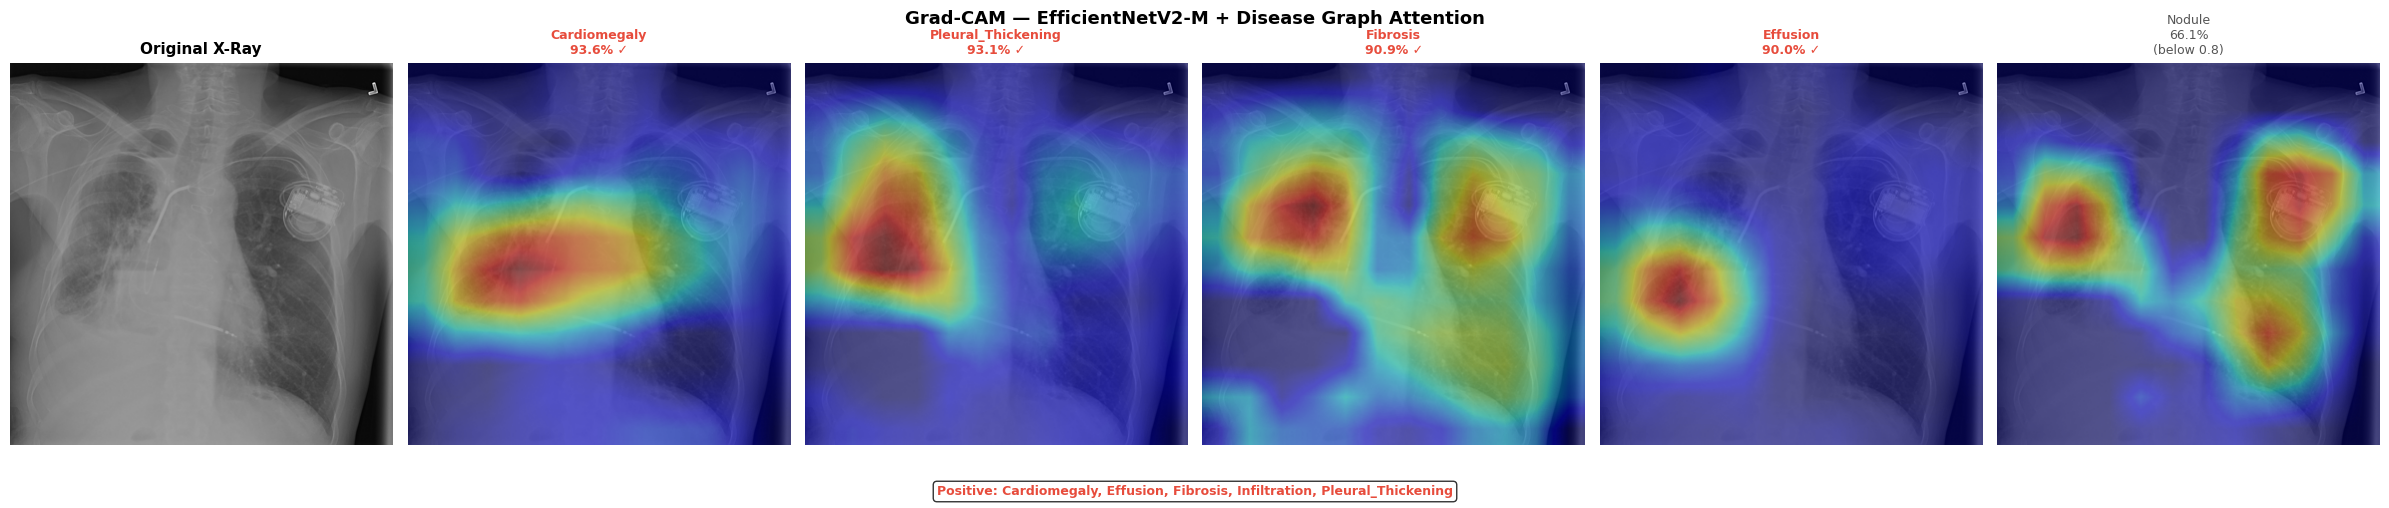


Grad-CAM saved → gradcam_output.png


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import cv2
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ---------- LABELS ----------
disease_labels = sorted([
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'No Finding', 'Nodule',
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
])

NUM_CLASSES = len(disease_labels)

# ---------- DISEASE GRAPH ATTENTION ----------
class DiseaseGraphAttention(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.A     = nn.Parameter(torch.eye(num_classes))
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        A_norm  = torch.softmax(self.A, dim=-1)
        refined = logits @ A_norm.t()
        return logits + torch.tanh(self.alpha) * refined

    def get_adjacency(self):
        with torch.no_grad():
            return torch.softmax(self.A, dim=-1).cpu().numpy()


# ---------- MODEL ----------
class EfficientNetV2Classifier(nn.Module):
    def __init__(self, num_classes, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_m',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        in_features     = self.backbone.num_features
        self.dropout    = nn.Dropout(0.5)
        self.classifier = nn.Linear(in_features, num_classes)
        self.graph_attn = DiseaseGraphAttention(num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.classifier(x)
        x = self.graph_attn(x)
        return x


# ---------- GRAD-CAM ----------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output  = self.model(input_tensor)
        score   = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1)
        cam     = torch.relu(cam)[0].cpu().numpy()

        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam


# ---------- LOAD MODEL ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetV2Classifier(NUM_CLASSES, pretrained=False).to(device)
model.load_state_dict(
    torch.load("/content/efficientnetv2_graph_cpu_weights.pth", map_location=device)
)
model.eval()

# ---------- TARGET LAYER ----------
target_layer = model.backbone.blocks[-1][-1]
grad_cam     = GradCAM(model, target_layer)

print("Model loaded successfully")
print(f"Device       : {device}")
print(f"Target layer : {target_layer.__class__.__name__}")
#print(f"Graph alpha  : {torch.tanh(model.graph_attn.alpha).item():.4f}")

# ---------- TRANSFORM ----------
transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ---------- PER-CLASS THRESHOLDS ----------
per_class_thresholds = {
    'Atelectasis'        : 0.80,
    'Cardiomegaly'       : 0.85,
    'Consolidation'      : 0.80,
    'Edema'              : 0.85,
    'Effusion'           : 0.80,
    'Emphysema'          : 0.85,
    'Fibrosis'           : 0.85,
    'Hernia'             : 0.85,
    'Infiltration'       : 0.60,
    'Mass'               : 0.80,
    'No Finding'         : 0.25,
    'Nodule'             : 0.80,
    'Pleural_Thickening' : 0.80,
    'Pneumonia'          : 0.85,
    'Pneumothorax'       : 0.80,
}

# ---------- PREDICT + GRAD-CAM ----------
def predict_and_gradcam(img_path, top_k=5):
    # --- load & prep image ---
    orig_img = Image.open(img_path).convert("RGB")
    orig_np  = np.array(orig_img.resize((384, 384)))

    input_tensor = transform(orig_img).unsqueeze(0).to(device)

    # --- inference ---
    with torch.no_grad():
        logits = model(input_tensor)
        probs  = torch.sigmoid(logits)[0].cpu().numpy()

    # --- evaluate per-class thresholds ---
    positives = []
    print("\n" + "="*55)
    print("  Prediction Probabilities (Per-Class Thresholds)")
    print("="*55)
    for lbl, p in zip(disease_labels, probs):
        thresh = per_class_thresholds[lbl]
        is_pos = p >= thresh
        if is_pos:
            positives.append(lbl)
        flag = f" <-- POSITIVE (threshold: {thresh})" if is_pos else f"  (threshold: {thresh})"
        print(f"  {lbl:<25} {p*100:>6.2f}%{flag}")
    print("="*55)

    # --- summary ---
    print(f"\n  Positive findings ({len(positives)}):")
    if positives:
        for p in positives:
            print(f"    ✓ {p}")
    else:
        print("    No findings detected")


    # --- Grad-CAM for top-k by probability ---
    top_indices = np.argsort(probs)[::-1][:top_k]

    fig, axes = plt.subplots(1, top_k + 1, figsize=(4 * (top_k + 1), 5))

    # column 0 — original
    axes[0].imshow(orig_np, cmap="gray")
    axes[0].set_title("Original X-Ray", fontsize=11, fontweight="bold")
    axes[0].axis("off")

    for col, cls_idx in enumerate(top_indices, start=1):
        lbl    = disease_labels[cls_idx]
        thresh = per_class_thresholds[lbl]
        is_pos = probs[cls_idx] >= thresh

        # fresh forward+backward per class
        inp = transform(orig_img).unsqueeze(0).to(device)
        inp.requires_grad_(True)
        cam = grad_cam.generate(inp, cls_idx)

        # upsample & overlay
        cam_resized = cv2.resize(cam, (384, 384))
        heatmap     = (cm.jet(cam_resized)[:, :, :3] * 255).astype(np.uint8)
        overlay     = (0.55 * orig_np + 0.45 * heatmap).astype(np.uint8)

        title_color  = "#e74c3c" if is_pos else "#555555"
        border_color = "#e74c3c" if is_pos else "#aaaaaa"
        status_icon  = " ✓" if is_pos else f"\n(below {thresh})"

        axes[col].imshow(overlay)
        axes[col].set_title(
            f"{lbl}\n{probs[cls_idx]*100:.1f}%{status_icon}",
            fontsize=9,
            color=title_color,
            fontweight="bold" if is_pos else "normal"
        )
        axes[col].axis("off")
        for spine in axes[col].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2.5)

    # --- positive findings summary box ---
    summary = "Positive: " + (", ".join(positives) if positives else "None")
    plt.figtext(0.5, 0.01, summary, ha="center", fontsize=9,
                color="#e74c3c" if positives else "#555555",
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.suptitle(
        "Grad-CAM — EfficientNetV2-M + Disease Graph Attention",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig("gradcam_output.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nGrad-CAM saved → gradcam_output.png")

    return probs, positives


# ---------- RUN ----------
probs, positives = predict_and_gradcam("test_xray.png", top_k=5)

Phase 2

In [ ]:
# ==================== REGION FOCUS FUNCTION ====================
def region_focus_percent(cam):
    h, w = cam.shape

    left  = cam[:, :int(w * 0.4)]
    mid   = cam[:, int(w * 0.4):int(w * 0.6)]
    right = cam[:, int(w * 0.6):]
    upper = cam[:int(h * 0.4), :]
    lower = cam[int(h * 0.6):, :]

    total_h = left.sum() + mid.sum() + right.sum() + 1e-8
    total_v = upper.sum() + lower.sum() + 1e-8

    return {
        "Left Lung %"  : float(left.sum()  / total_h * 100),
        "Mediastinum %" : float(mid.sum()   / total_h * 100),
        "Right Lung %"  : float(right.sum() / total_h * 100),
        "Upper Zone %"  : float(upper.sum() / total_v * 100),
        "Lower Zone %"  : float(lower.sum() / total_v * 100),
    }


# ==================== ACTIVATION STATS ====================
def compute_activation_stats(cam_resized):
    return {
        "max_activation"          : float(cam_resized.max()),
        "mean_activation"         : float(cam_resized.mean()),
        "activated_area_percent"  : float((cam_resized > 0.6).sum() / cam_resized.size * 100),
        "high_confidence_area_%"  : float((cam_resized > 0.8).sum() / cam_resized.size * 100),
        "focus_sharpness"         : float(cam_resized.max() - cam_resized.mean()),
    }


# ==================== CONFIDENCE TIER ====================
def get_confidence_tier(prob, threshold):
    margin = prob - threshold
    if margin >= 0.08:
        return "High Confidence",  "#e74c3c"
    elif margin >= 0.04:
        return "Borderline",       "#e67e22"
    else:
        return "Low Confidence",   "#f39c12"


# ==================== GRADCAM GENERATE (NO DISPLAY) ====================
def generate_cam_silent(img_path, class_index):
    """
    Runs Grad-CAM for a single class with zero display/plotting.
    Returns only the raw CAM array + stats + regions.
    """
    img = Image.open(img_path).convert("RGB")

    inp = transform(img).unsqueeze(0).to(device)
    inp.requires_grad_(True)
    cam = grad_cam.generate(inp, class_index)

    if len(cam.shape) == 3:
        cam = cam.mean(axis=0)

    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    cam_resized = cv2.resize(cam, (384, 384))

    stats   = compute_activation_stats(cam_resized)
    regions = region_focus_percent(cam_resized)

    return cam_resized, stats, regions


# ==================== GRADCAM TO TEXT ====================
def gradcam_to_text(lbl, prob, stats, regions):

    thresh     = per_class_thresholds[lbl]
    margin     = prob - thresh
    is_pos     = prob >= thresh
    confidence, _ = get_confidence_tier(prob, thresh) if is_pos else ("Below Threshold", None)

    # --- activation strength ---
    if stats["max_activation"] > 0.9:
        strength = "very strong"
    elif stats["max_activation"] > 0.6:
        strength = "strong"
    elif stats["max_activation"] > 0.3:
        strength = "moderate"
    else:
        strength = "weak"

    # --- spread ---
    if stats["activated_area_percent"] < 3:
        spread = "highly localized"
    elif stats["activated_area_percent"] < 10:
        spread = "moderately localized"
    else:
        spread = "diffuse"

    # --- dominant horizontal region only ---
    horiz_regions  = {k: v for k, v in regions.items()
                      if k in ["Left Lung %", "Mediastinum %", "Right Lung %"]}
    dominant_horiz = max(horiz_regions, key=horiz_regions.get).replace('%', '').strip().lower()

    text = f"""
Grad-CAM Analysis — {lbl} ({prob*100:.1f}%, {confidence}):

  • Maximum activation value is {stats['max_activation']:.2f}, indicating {strength} model confidence in the highlighted region.

  • Mean activation across the image is {stats['mean_activation']:.2f}.

  • Activated area covers {stats['activated_area_percent']:.2f}% of the chest X-ray, suggesting the attention is {spread}.

  • Regional attention distribution:
      - Left Lung   : {regions['Left Lung %']:.1f}%
      - Mediastinum : {regions['Mediastinum %']:.1f}%
      - Right Lung  : {regions['Right Lung %']:.1f}%

  • The model primarily focused on the {dominant_horiz} region.
"""
    return text


# ==================== RUN PHASE 2 (TEXT ONLY) ====================
def run_phase2_text_only(img_path, positives, probs):
    """
    Runs Phase 2 in text-only mode — no plots, no image saves.
    Designed to feed directly into Phase 3 RAG + LLM pipeline.

    Parameters
    ----------
    img_path  : str        – path to chest X-ray
    positives : list       – positive disease names from Phase 1
    probs     : np.ndarray – full probability array from Phase 1

    Returns
    -------
    phase2_results : dict – per-disease cam/stats/regions/text
    all_reports    : dict – per-disease text report strings
    combined_text  : str  – single string of all reports (LLM input ready)
    """

    # --- build results sorted by margin ---
    results = []
    for lbl in positives:
        idx    = disease_labels.index(lbl)
        prob   = float(probs[idx])
        thresh = per_class_thresholds[lbl]
        margin = prob - thresh
        results.append((margin, idx, lbl, prob, thresh))

    results.sort(reverse=True)

    print(f"\n{'='*55}")
    print(f"  Phase 2 — Text Analysis ({len(results)} positive findings)")
    print(f"  Ordered by confidence margin (highest first)")
    print(f"{'='*55}\n")

    print(f"  {'Rank':<6}{'Finding':<25}{'Prob':>7}  {'Margin':>8}  {'Tier'}")
    print(f"  {'-'*55}")
    for rank, (margin, idx, lbl, prob, thresh) in enumerate(results, 1):
        conf, _ = get_confidence_tier(prob, thresh)
        print(f"  {rank:<6}{lbl:<25}{prob*100:>6.1f}%  {margin*100:>+7.1f}%  {conf}")

    print(f"\n  {'─'*55}")
    print(f"  High Confidence : margin ≥ +8%")
    print(f"  Borderline      : margin +4% to +8%")
    print(f"  Low Confidence  : margin < +4%")
    print(f"  {'─'*55}\n")

    # --- generate CAM + text per disease ---
    phase2_results = {}
    all_reports    = {}

    for margin, idx, lbl, prob, thresh in results:
        print(f"  Processing: {lbl} ({prob*100:.1f}%) ...", end=" ")

        cam, stats, regions = generate_cam_silent(img_path, idx)
        report_text         = gradcam_to_text(lbl, prob, stats, regions)

        phase2_results[lbl] = {
            "cam"    : cam,
            "stats"  : stats,
            "regions": regions,
            "prob"   : prob,
            "margin" : margin,
            "text"   : report_text
        }
        all_reports[lbl] = report_text
        print("done ✓")
        print(report_text)

    # --- combine all text into one string for LLM ---
    combined_text = "\n".join(all_reports.values())

    print(f"\n  Phase 2 complete — text ready for Phase 3 pipeline")
    return phase2_results, all_reports, combined_text


# ==================== RUN ====================
phase2_results, all_reports, combined_text = run_phase2_text_only(
    img_path  = "test_xray.png",
    positives = positives,   # from Phase 1
    probs     = probs        # from Phase 1
)


  Phase 2 — Text Analysis (5 positive findings)
  Ordered by confidence margin (highest first)

  Rank  Finding                     Prob    Margin  Tier
  -------------------------------------------------------
  1     Pleural_Thickening         93.1%    +13.1%  High Confidence
  2     Effusion                   90.0%    +10.0%  High Confidence
  3     Cardiomegaly               93.6%     +8.6%  High Confidence
  4     Fibrosis                   90.9%     +5.9%  Borderline
  5     Infiltration               64.5%     +4.5%  Borderline

  ───────────────────────────────────────────────────────
  High Confidence : margin ≥ +8%
  Borderline      : margin +4% to +8%
  Low Confidence  : margin < +4%
  ───────────────────────────────────────────────────────

  Processing: Pleural_Thickening (93.1%) ... done ✓

Grad-CAM Analysis — Pleural_Thickening (93.1%, High Confidence):

  • Maximum activation value is 1.00, indicating very strong model confidence in the highlighted region.

  • Mean ac

Phase 3

In [ ]:
!pip install -q transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00


In [ ]:
!pip install groq -q

from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
print("Groq API key loaded ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 14.4 MB/s eta 0:00:00
Groq API key loaded ✓


In [ ]:
import json

with open("medical_knowledge.json", "r") as f:
    RAG_DATABASE = json.load(f)

print("RAG database loaded ✓")
print(f"Diseases loaded: {list(RAG_DATABASE.keys())}")

RAG database loaded ✓
Diseases loaded: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


Phase 3

In [ ]:
# ==================== PHASE 3 — RAG + GROQ + REPORT ====================

from groq import Groq

# ==================== LOAD RAG DATABASE ====================
with open("medical_knowledge.json", "r") as f:
    RAG_DATABASE = json.load(f)

print(f"RAG database loaded ✓  —  {len(RAG_DATABASE)} diseases")


# ==================== RAG RETRIEVAL ====================
def retrieve_rag_context(positives):
    context_blocks = []
    for lbl in positives:
        if lbl not in RAG_DATABASE:
            continue
        entry         = RAG_DATABASE[lbl]
        definition    = entry.get("definition", [])
        xray_findings = entry.get("xray_key_findings", [])
        signs         = entry.get("named_radiology_signs", [])
        location      = entry.get("typical_location", [])

        block = f"""
DISEASE: {lbl}
─────────────────────────────────────────
DEFINITION:
{definition[0] if definition else 'N/A'}

KEY X-RAY FINDINGS:
{chr(10).join(f'  • {f}' for f in xray_findings[:4])}

NAMED RADIOLOGY SIGNS:
{chr(10).join(f'  • {s}' for s in signs[:3])}

TYPICAL LOCATION:
{chr(10).join(f'  • {l}' for l in location[:3])}
"""
        context_blocks.append(block)
    return "\n".join(context_blocks)


# ==================== BUILD PROMPT ====================
def build_prompt(img_path, probs, positives, phase2_results, combined_text):
    phase1_summary = "DETECTION RESULTS (ordered by confidence margin):\n"
    sorted_findings = sorted(
        [(lbl, phase2_results[lbl]) for lbl in positives],
        key=lambda x: x[1]["margin"],
        reverse=True
    )
    for rank, (lbl, data) in enumerate(sorted_findings, 1):
        conf, _ = get_confidence_tier(data["prob"], per_class_thresholds[lbl])
        phase1_summary += (f"  {rank}. {lbl:<25} "
                          f"{data['prob']*100:.1f}%  "
                          f"margin: {data['margin']*100:+.1f}%  "
                          f"→ {conf}\n")

    rag_context    = retrieve_rag_context(positives)
    all_probs_text = "ALL CLASS PROBABILITIES:\n"
    for lbl, p in zip(disease_labels, probs):
        thresh = per_class_thresholds[lbl]
        flag   = " ← POSITIVE" if p >= thresh else ""
        all_probs_text += f"  {lbl:<25} {p*100:.1f}%{flag}\n"

    prompt = f"""You are an expert radiologist AI assistant generating a formal clinical radiology report based on automated chest X-ray analysis.

You have been provided with:
1. AI model detection results with confidence scores
2. Grad-CAM visual attention analysis describing WHERE the model focused
3. Clinical reference knowledge for each detected finding

Generate a structured, formal radiology report in the style of a real clinical radiologist's report.

{'='*70}
SECTION 1 — AI MODEL DETECTION RESULTS
{'='*70}
{phase1_summary}
{all_probs_text}

{'='*70}
SECTION 2 — GRAD-CAM VISUAL ATTENTION ANALYSIS
{'='*70}
{combined_text}

{'='*70}
SECTION 3 — CLINICAL REFERENCE KNOWLEDGE (RAG)
{'='*70}
{rag_context}

{'='*70}
REPORT GENERATION INSTRUCTIONS
{'='*70}
Generate a formal radiology report with EXACTLY these sections:

1. CLINICAL INDICATION
   Brief statement of why the X-ray was performed (AI-assisted screening).

2. TECHNIQUE
   Standard PA chest radiograph with AI-assisted analysis using EfficientNetV2-M
   with Disease Graph Attention (Macro AUC: 0.8122).

3. FINDINGS
   For each POSITIVE finding write 2-3 sentences describing:
   - What was detected and where (use Grad-CAM regional focus data)
   - Confidence level (High Confidence / Borderline tone)
   - Relevant radiological characteristics from the clinical reference
   Order findings from highest to lowest confidence margin.
   Use HIGH CONFIDENCE tone for margin ≥ +8%.
   Use BORDERLINE/CAUTIOUS tone for margin +4% to +8%.

4. IMPRESSION
   3-5 sentence clinical summary:
   - Lead with most significant High Confidence findings
   - Note clinically coherent co-occurrence patterns if present
   - End with recommendation for clinical correlation

5. DISCLAIMER
   Standard AI disclaimer: this report is generated by an automated AI system
   and must be reviewed and verified by a qualified radiologist before
   clinical use.

Write in formal clinical language. Be specific about anatomical locations.
Do not speculate beyond what the data supports.
For Borderline findings use phrases like 'possible', 'cannot be excluded',
'clinical correlation advised'.
"""
    return prompt


# ==================== GROQ LLM CALL ====================
def generate_report_groq(prompt):
    client   = Groq(api_key=os.environ["GROQ_API_KEY"])
    print("  Sending to Groq LLaMA3-70B ...", end=" ")
    response = client.chat.completions.create(
        model    = "llama-3.3-70b-versatile",
        messages = [
            {
                "role"   : "system",
                "content": (
                    "You are a senior radiologist generating formal clinical "
                    "radiology reports. Your reports are precise, evidence-based, "
                    "and follow standard radiology reporting conventions. "
                    "You always clearly distinguish between high confidence findings "
                    "and borderline findings."
                )
            },
            {
                "role"   : "user",
                "content": prompt
            }
        ],
        temperature = 0.3,
        max_tokens  = 1500,
    )
    print("done ✓")
    return response.choices[0].message.content


# ==================== FULL PHASE 3 PIPELINE ====================
def run_phase3(img_path, probs, positives, phase2_results, combined_text):
    print(f"\n{'='*55}")
    print(f"  Phase 3 — RAG + LLM Report Generation")
    print(f"{'='*55}\n")

    print("  Step 1: Retrieving RAG context ...", end=" ")
    rag_context = retrieve_rag_context(positives)
    print(f"done ✓ ({len(positives)} diseases retrieved)")

    print("  Step 2: Building LLM prompt ...", end=" ")
    prompt = build_prompt(
        img_path       = img_path,
        probs          = probs,
        positives      = positives,
        phase2_results = phase2_results,
        combined_text  = combined_text
    )
    print(f"done ✓ (~{len(prompt.split())} words)")

    print("  Step 3: Generating report via Groq LLaMA3-70B ...")
    report_text = generate_report_groq(prompt)

    print(f"\n{'#'*60}")
    print(f"  GENERATED CLINICAL REPORT")
    print(f"{'#'*60}\n")
    print(report_text)
    print(f"\n{'#'*60}")
    print(f"  Phase 3 complete — report ready for Phase 4 (PDF)")
    print(f"{'#'*60}")

    return report_text, prompt


# ==================== RUN ====================
report_text, prompt = run_phase3(
    img_path       = "test_xray.png",
    probs          = probs,
    positives      = positives,
    phase2_results = phase2_results,
    combined_text  = combined_text
)

RAG database loaded ✓  —  14 diseases

  Phase 3 — RAG + LLM Report Generation

  Step 1: Retrieving RAG context ... done ✓ (5 diseases retrieved)
  Step 2: Building LLM prompt ... done ✓ (~1656 words)
  Step 3: Generating report via Groq LLaMA3-70B ...
  Sending to Groq LLaMA3-70B ... done ✓

############################################################
  GENERATED CLINICAL REPORT
############################################################

**CLINICAL INDICATION**
The chest X-ray was performed as part of an AI-assisted screening protocol to evaluate the patient's thoracic cavity for potential abnormalities.

**TECHNIQUE**
The examination consisted of a standard posteroanterior (PA) chest radiograph, which was analyzed using an AI-assisted system employing the EfficientNetV2-M model with Disease Graph Attention, yielding a macro AUC of 0.8122.

**FINDINGS**
1. **Pleural Thickening**: High confidence detection (93.1%, margin: +13.1%) with the model primarily focusing on the left lung re

Phase 4

In [ ]:
# ==================== PHASE 4 — CLINICAL PDF REPORT ====================

!pip install reportlab -q

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                 Table, TableStyle, HRFlowable,
                                 Image as RLImage, PageBreak)
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
from datetime import datetime
import io
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import numpy as np
from PIL import Image as PILImage

print("ReportLab loaded ✓")


# ==================== GENERATE HEATMAP IMAGES ====================
def generate_heatmap_images(img_path, phase2_results, max_images=3):
    orig_img = PILImage.open(img_path).convert("RGB")
    orig_np  = np.array(orig_img.resize((384, 384)))

    sorted_findings = sorted(
        phase2_results.items(),
        key=lambda x: x[1]["margin"],
        reverse=True
    )[:max_images]

    heatmap_buffers = []

    for lbl, data in sorted_findings:
        cam         = data["cam"]
        cam_resized = cv2.resize(cam, (384, 384))
        heatmap     = (cm.jet(cam_resized)[:, :, :3] * 255).astype(np.uint8)
        overlay     = (0.55 * orig_np + 0.45 * heatmap).astype(np.uint8)

        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        axes[0].imshow(orig_np, cmap="gray")
        axes[0].set_title("Original", fontsize=8)
        axes[0].axis("off")
        axes[1].imshow(overlay)
        axes[1].set_title(f"{lbl}\n{data['prob']*100:.1f}%", fontsize=8)
        axes[1].axis("off")
        plt.tight_layout()

        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=100, bbox_inches="tight")
        plt.close()
        buf.seek(0)
        heatmap_buffers.append((lbl, buf))

    return heatmap_buffers


# ==================== PARSE REPORT SECTIONS (FIXED) ====================
def parse_report_sections(report_text):
    # Strip markdown bold/italic markers
    clean = report_text.replace("**", "").replace("__", "")

    sections = {
        "clinical_indication": "",
        "technique":           "",
        "findings":            "",
        "impression":          "",
        "disclaimer":          ""
    }

    # Map every possible header the LLM might produce → section key
    header_map = {
        "CLINICAL INDICATION": "clinical_indication",
        "TECHNIQUE":           "technique",
        "FINDINGS":            "findings",
        "IMPRESSION":          "impression",
        "DISCLAIMER":          "disclaimer",
    }

    current_key  = None
    buffer_lines = []

    for line in clean.splitlines():
        stripped = line.strip()

        # Normalize: strip leading numbers, dots, spaces
        # e.g. "1. CLINICAL INDICATION" → "CLINICAL INDICATION"
        # e.g. "  CLINICAL INDICATION"  → "CLINICAL INDICATION"
        normalized = stripped.lstrip("12345. ").upper()

        matched_key = None
        for header, key in header_map.items():
            if normalized == header or normalized.startswith(header):
                matched_key = key
                break

        if matched_key:
            # Save buffered content under the previous section
            if current_key and buffer_lines:
                sections[current_key] = "\n".join(buffer_lines).strip()
            # Switch to new section, reset buffer
            current_key  = matched_key
            buffer_lines = []
        else:
            if current_key:
                buffer_lines.append(line)

    # Save the last section
    if current_key and buffer_lines:
        sections[current_key] = "\n".join(buffer_lines).strip()

    # DEBUG — remove after confirming sections are populated
    print("\n[DEBUG] Parsed section lengths:")
    for k, v in sections.items():
        print(f"  {k:<25} {len(v)} chars  |  preview: {v[:80].strip()!r}")

    return sections


# ==================== BUILD PDF ====================
def generate_clinical_pdf(
    img_path,
    report_text,
    phase2_results,
    probs,
    positives,
    output_path="clinical_report.pdf"
):
    doc = SimpleDocTemplate(
        output_path,
        pagesize       = A4,
        rightMargin    = 20*mm,
        leftMargin     = 20*mm,
        topMargin      = 20*mm,
        bottomMargin   = 20*mm
    )

    # ---- colour palette ----
    DARK_BLUE   = colors.HexColor("#1a2e4a")
    MID_BLUE    = colors.HexColor("#2c5282")
    LIGHT_BLUE  = colors.HexColor("#ebf4ff")
    RED         = colors.HexColor("#e74c3c")
    ORANGE      = colors.HexColor("#e67e22")
    GREEN       = colors.HexColor("#27ae60")
    LIGHT_GREY  = colors.HexColor("#f7f9fc")
    MID_GREY    = colors.HexColor("#cccccc")
    TEXT_DARK   = colors.HexColor("#1a1a2e")

    # ---- styles ----
    styles = getSampleStyleSheet()

    style_title = ParagraphStyle(
        "ReportTitle",
        fontSize    = 18,
        fontName    = "Helvetica-Bold",
        textColor   = DARK_BLUE,
        alignment   = TA_CENTER,
        spaceAfter  = 4
    )
    style_subtitle = ParagraphStyle(
        "SubTitle",
        fontSize    = 10,
        fontName    = "Helvetica",
        textColor   = MID_BLUE,
        alignment   = TA_CENTER,
        spaceAfter  = 2
    )
    style_section = ParagraphStyle(
        "SectionHeader",
        fontSize    = 11,
        fontName    = "Helvetica-Bold",
        textColor   = colors.white,
        spaceAfter  = 6,
        spaceBefore = 10,
        leftIndent  = 4
    )
    style_body = ParagraphStyle(
        "Body",
        fontSize    = 9,
        fontName    = "Helvetica",
        textColor   = TEXT_DARK,
        leading     = 14,
        alignment   = TA_JUSTIFY,
        spaceAfter  = 4
    )
    style_body_bold = ParagraphStyle(
        "BodyBold",
        fontSize    = 9,
        fontName    = "Helvetica-Bold",
        textColor   = TEXT_DARK,
        leading     = 14,
        spaceAfter  = 2
    )
    style_disclaimer = ParagraphStyle(
        "Disclaimer",
        fontSize    = 8,
        fontName    = "Helvetica-Oblique",
        textColor   = colors.HexColor("#666666"),
        leading     = 12,
        alignment   = TA_JUSTIFY
    )
    style_meta = ParagraphStyle(
        "Meta",
        fontSize    = 8,
        fontName    = "Helvetica",
        textColor   = colors.HexColor("#555555"),
        alignment   = TA_LEFT
    )

    story = []

    # ======================================================
    # HEADER
    # ======================================================
    story.append(Paragraph("AUTOMATED CHEST X-RAY ANALYSIS REPORT", style_title))
    story.append(Paragraph("AI-Assisted Radiology Screening — EfficientNetV2-M + Disease Graph Attention", style_subtitle))
    story.append(HRFlowable(width="100%", thickness=2, color=DARK_BLUE, spaceAfter=6))

    # ---- metadata table ----
    now = datetime.now()
    meta_data = [
        ["Report Date:", now.strftime("%B %d, %Y"),
         "Report Time:", now.strftime("%H:%M:%S")],
        ["Model:",       "EfficientNetV2-M + DGA",
         "Macro AUC:",   "0.8122 (95% CI: 0.8082–0.8161)"],
        ["Image File:",  img_path,
         "Findings:",    f"{len(positives)} positive finding(s)"],
    ]
    meta_table = Table(meta_data, colWidths=[35*mm, 65*mm, 35*mm, 55*mm])
    meta_table.setStyle(TableStyle([
        ("FONTNAME",    (0, 0), (-1, -1), "Helvetica"),
        ("FONTNAME",    (0, 0), (0, -1), "Helvetica-Bold"),
        ("FONTNAME",    (2, 0), (2, -1), "Helvetica-Bold"),
        ("FONTSIZE",    (0, 0), (-1, -1), 8),
        ("TEXTCOLOR",   (0, 0), (-1, -1), TEXT_DARK),
        ("BACKGROUND",  (0, 0), (-1, -1), LIGHT_GREY),
        ("ROWBACKGROUNDS", (0, 0), (-1, -1), [LIGHT_GREY, colors.white]),
        ("GRID",        (0, 0), (-1, -1), 0.3, MID_GREY),
        ("PADDING",     (0, 0), (-1, -1), 4),
    ]))
    story.append(meta_table)
    story.append(Spacer(1, 8*mm))

    # ======================================================
    # FINDINGS SUMMARY TABLE
    # ======================================================
    def section_header(title):
        header_table = Table(
            [[Paragraph(title, style_section)]],
            colWidths=[170*mm]
        )
        header_table.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, -1), DARK_BLUE),
            ("PADDING",    (0, 0), (-1, -1), 5),
        ]))
        return header_table

    story.append(section_header("FINDINGS SUMMARY"))
    story.append(Spacer(1, 2*mm))

    sorted_findings = sorted(
        [(lbl, phase2_results[lbl]) for lbl in positives],
        key=lambda x: x[1]["margin"],
        reverse=True
    )

    table_data = [["#", "Finding", "Probability", "Margin", "Confidence Tier"]]
    for rank, (lbl, data) in enumerate(sorted_findings, 1):
        conf, _  = get_confidence_tier(data["prob"], per_class_thresholds[lbl])
        margin   = data["margin"] * 100
        table_data.append([
            str(rank),
            lbl.replace("_", " "),
            f"{data['prob']*100:.1f}%",
            f"{margin:+.1f}%",
            conf
        ])

    col_widths = [10*mm, 55*mm, 30*mm, 25*mm, 50*mm]
    summary_table = Table(table_data, colWidths=col_widths)

    tier_colors = {
        "High Confidence" : colors.HexColor("#fde8e8"),
        "Borderline"      : colors.HexColor("#fef3e2"),
        "Low Confidence"  : colors.HexColor("#fffde7"),
    }
    table_style = [
        ("BACKGROUND",  (0, 0), (-1, 0),  DARK_BLUE),
        ("TEXTCOLOR",   (0, 0), (-1, 0),  colors.white),
        ("FONTNAME",    (0, 0), (-1, 0),  "Helvetica-Bold"),
        ("FONTSIZE",    (0, 0), (-1, -1), 8.5),
        ("ALIGN",       (0, 0), (-1, -1), "CENTER"),
        ("ALIGN",       (1, 0), (1, -1),  "LEFT"),
        ("GRID",        (0, 0), (-1, -1), 0.3, MID_GREY),
        ("PADDING",     (0, 0), (-1, -1), 5),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [LIGHT_GREY, colors.white]),
    ]
    for i, (lbl, data) in enumerate(sorted_findings, 1):
        conf, _ = get_confidence_tier(data["prob"], per_class_thresholds[lbl])
        bg      = tier_colors.get(conf, colors.white)
        table_style.append(("BACKGROUND", (0, i), (-1, i), bg))

    summary_table.setStyle(TableStyle(table_style))
    story.append(summary_table)
    story.append(Spacer(1, 6*mm))

    # ======================================================
    # PARSE REPORT SECTIONS
    # ======================================================
    sections = parse_report_sections(report_text)

    def render_section(title, content):
        story.append(section_header(title))
        story.append(Spacer(1, 2*mm))
        for line in content.split("\n"):
            line = line.strip()
            if not line:
                story.append(Spacer(1, 2*mm))
                continue
            if line and line[0].isdigit() and "." in line[:3]:
                parts = line.split(":", 1)
                if len(parts) == 2:
                    story.append(Paragraph(
                        f"<b>{parts[0]}:</b>{parts[1]}",
                        style_body
                    ))
                else:
                    story.append(Paragraph(line, style_body))
            else:
                story.append(Paragraph(line, style_body))
        story.append(Spacer(1, 3*mm))

    render_section("1. CLINICAL INDICATION", sections["clinical_indication"])
    render_section("2. TECHNIQUE",           sections["technique"])
    render_section("3. FINDINGS",            sections["findings"])
    render_section("4. IMPRESSION",          sections["impression"])

    # ======================================================
    # GRAD-CAM HEATMAPS (top 3 findings)
    # ======================================================
    story.append(section_header("GRAD-CAM VISUAL ATTENTION MAPS (Top 3 Findings)"))
    story.append(Spacer(1, 3*mm))
    story.append(Paragraph(
        "The following heatmaps illustrate the regions of the chest X-ray "
        "that most strongly influenced the AI model's predictions. "
        "Red/yellow regions indicate highest model attention.",
        style_body
    ))
    story.append(Spacer(1, 3*mm))

    heatmap_buffers = generate_heatmap_images(img_path, phase2_results, max_images=3)
    heatmap_row     = []
    for lbl, buf in heatmap_buffers:
        img_obj = RLImage(buf, width=55*mm, height=30*mm)
        heatmap_row.append(img_obj)

    if heatmap_row:
        while len(heatmap_row) < 3:
            heatmap_row.append(Paragraph("", style_body))
        heatmap_table = Table([heatmap_row], colWidths=[57*mm, 57*mm, 57*mm])
        heatmap_table.setStyle(TableStyle([
            ("ALIGN",   (0, 0), (-1, -1), "CENTER"),
            ("VALIGN",  (0, 0), (-1, -1), "MIDDLE"),
            ("PADDING", (0, 0), (-1, -1), 3),
            ("GRID",    (0, 0), (-1, -1), 0.3, MID_GREY),
        ]))
        story.append(heatmap_table)

    story.append(Spacer(1, 6*mm))

    # ======================================================
    # ALL PROBABILITIES TABLE
    # ======================================================
    story.append(section_header("COMPLETE PROBABILITY SCORES"))
    story.append(Spacer(1, 2*mm))

    prob_data = [["Finding", "Probability", "Threshold", "Status"]]
    for lbl, p in zip(disease_labels, probs):
        thresh = per_class_thresholds[lbl]
        is_pos = p >= thresh
        status = "POSITIVE" if is_pos else "negative"
        prob_data.append([
            lbl.replace("_", " "),
            f"{p*100:.1f}%",
            f"{thresh*100:.0f}%",
            status
        ])

    prob_table = Table(prob_data, colWidths=[60*mm, 30*mm, 30*mm, 50*mm])
    prob_style = [
        ("BACKGROUND", (0, 0), (-1, 0),  DARK_BLUE),
        ("TEXTCOLOR",  (0, 0), (-1, 0),  colors.white),
        ("FONTNAME",   (0, 0), (-1, 0),  "Helvetica-Bold"),
        ("FONTSIZE",   (0, 0), (-1, -1), 8),
        ("ALIGN",      (0, 0), (-1, -1), "CENTER"),
        ("ALIGN",      (0, 0), (0, -1),  "LEFT"),
        ("GRID",       (0, 0), (-1, -1), 0.3, MID_GREY),
        ("PADDING",    (0, 0), (-1, -1), 4),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [LIGHT_GREY, colors.white]),
    ]
    for i, (lbl, p) in enumerate(zip(disease_labels, probs), 1):
        if p >= per_class_thresholds[lbl]:
            prob_style.append(("BACKGROUND", (0, i), (-1, i),
                               colors.HexColor("#fde8e8")))
            prob_style.append(("TEXTCOLOR",  (3, i), (3, i), RED))
            prob_style.append(("FONTNAME",   (3, i), (3, i), "Helvetica-Bold"))

    prob_table.setStyle(TableStyle(prob_style))
    story.append(prob_table)
    story.append(Spacer(1, 6*mm))

    # ======================================================
    # DISCLAIMER
    # ======================================================
    story.append(HRFlowable(width="100%", thickness=1, color=MID_GREY, spaceAfter=4))
    story.append(section_header("5. DISCLAIMER"))
    story.append(Spacer(1, 2*mm))
    disclaimer_text = sections.get("disclaimer") or (
        "This report has been generated by an automated artificial intelligence "
        "system and is intended for research and educational purposes only. "
        "It must be reviewed and verified by a qualified and licensed radiologist "
        "or physician before any clinical decisions are made. The AI model may "
        "produce false positives or false negatives. This report does not "
        "constitute medical advice and should not be used as a substitute for "
        "professional medical judgment."
    )
    story.append(Paragraph(disclaimer_text, style_disclaimer))
    story.append(Spacer(1, 4*mm))

    # ---- footer ----
    story.append(HRFlowable(width="100%", thickness=1, color=MID_GREY, spaceAfter=4))
    story.append(Paragraph(
        f"Generated: {now.strftime('%B %d, %Y at %H:%M:%S')}  |  "
        f"Model: EfficientNetV2-M + Disease Graph Attention  |  "
        f"Macro AUC: 0.8122",
        ParagraphStyle("Footer", fontSize=7, fontName="Helvetica",
                       textColor=colors.HexColor("#888888"), alignment=TA_CENTER)
    ))

    # ======================================================
    # BUILD
    # ======================================================
    doc.build(story)
    print(f"\n  PDF saved → {output_path}")
    return output_path


# ==================== RUN PHASE 4 ====================
print("="*55)
print("  Phase 4 — Clinical PDF Report Generation")
print("="*55)

output_path = generate_clinical_pdf(
    img_path       = "test_xray.png",
    report_text    = report_text,
    phase2_results = phase2_results,
    probs          = probs,
    positives      = positives,
    output_path    = "clinical_report.pdf"
)

from google.colab import files
files.download("clinical_report.pdf")

print("\n  Pipeline complete! All 4 phases executed successfully.")
print("  clinical_report.pdf downloaded to your computer.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 86.7 MB/s eta 0:00:00
ReportLab loaded ✓
  Phase 4 — Clinical PDF Report Generation

[DEBUG] Parsed section lengths:
  clinical_indication       145 chars  |  preview: 'The chest X-ray was performed as part of an AI-assisted screening protocol to ev'
  technique                 224 chars  |  preview: 'The examination consisted of a standard posteroanterior (PA) chest radiograph, w'
  findings                  2038 chars  |  preview: '1. Pleural Thickening: High confidence detection (93.1%, margin: +13.1%) with th'
  impression                671 chars  |  preview: 'The most significant findings in this examination are the high confidence detect'
  disclaimer                304 chars  |  preview: 'This report is generated by an automated AI system and must be reviewed and veri'

  PDF saved → clinical_report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  Pipeline complete! All 4 phases executed successfully.
  clinical_report.pdf downloaded to your computer.


Phase 5

In [ ]:
# ==================== CELL: FULL PIPELINE + GRADIO UI ====================
# Paste this into a new cell AFTER all Phase 1–4 cells have been run.

import gradio as gr
import shutil
import traceback
from datetime import datetime

# ==================== FULL PIPELINE FUNCTION ====================

def run_full_pipeline(img_path: str) -> str:
    """
    End-to-end chest X-ray analysis pipeline.

    Parameters
    ----------
    img_path : str
        Path to the uploaded chest X-ray image.

    Returns
    -------
    str
        Absolute path to the generated clinical PDF report.

    Raises
    ------
    RuntimeError
        If any phase fails, a descriptive error is raised.
    """

    timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_pdf  = f"clinical_report_{timestamp}.pdf"

    print("\n" + "="*60)
    print("  END-TO-END CHEST X-RAY ANALYSIS PIPELINE")
    print("="*60)

    # ── Phase 1 ─────────────────────────────────────────────────
    print("\n[1/4] Phase 1 — Disease Detection ...")
    try:
        probs, positives = predict_and_gradcam(img_path, top_k=5)
        print(f"  ✓  Positive findings : {positives if positives else 'None'}")
    except Exception as e:
        raise RuntimeError(f"Phase 1 failed:\n{traceback.format_exc()}") from e

    # ── Phase 2 ─────────────────────────────────────────────────
    print("\n[2/4] Phase 2 — Grad-CAM Explainability ...")
    try:
        if not positives:
            # No positive findings — still build empty-safe outputs
            phase2_results = {}
            all_reports    = {}
            combined_text  = "No positive findings detected by the model."
            print("  ✓  No positives — skipping Grad-CAM text analysis")
        else:
            phase2_results, all_reports, combined_text = run_phase2_text_only(
                img_path  = img_path,
                positives = positives,
                probs     = probs
            )
            print(f"  ✓  Grad-CAM reports generated for {len(phase2_results)} finding(s)")
    except Exception as e:
        raise RuntimeError(f"Phase 2 failed:\n{traceback.format_exc()}") from e

    # ── Phase 3 ─────────────────────────────────────────────────
    print("\n[3/4] Phase 3 — RAG + LLM Report Generation ...")
    try:
        report_text, _ = run_phase3(
            img_path       = img_path,
            probs          = probs,
            positives      = positives,
            phase2_results = phase2_results,
            combined_text  = combined_text
        )
        print(f"  ✓  Report generated ({len(report_text.split())} words)")
    except Exception as e:
        raise RuntimeError(f"Phase 3 failed:\n{traceback.format_exc()}") from e

    # ── Phase 4 ─────────────────────────────────────────────────
    print("\n[4/4] Phase 4 — Clinical PDF Generation ...")
    try:
        output_path = generate_clinical_pdf(
            img_path       = img_path,
            report_text    = report_text,
            phase2_results = phase2_results,
            probs          = probs,
            positives      = positives,
            output_path    = output_pdf
        )
        print(f"  ✓  PDF saved → {output_path}")
    except Exception as e:
        raise RuntimeError(f"Phase 4 failed:\n{traceback.format_exc()}") from e

    print("\n" + "="*60)
    print(f"  PIPELINE COMPLETE — {output_path}")
    print("="*60 + "\n")

    return output_path


# ==================== GRADIO INTERFACE ====================

def gradio_pipeline(uploaded_image):
    """
    Gradio-compatible wrapper around run_full_pipeline().
    Converts the Gradio PIL upload to a saved file path,
    then returns the PDF path for Gradio's File component.
    """
    if uploaded_image is None:
        raise gr.Error("Please upload a chest X-ray image before running the analysis.")

    # Gradio passes a PIL Image — save it to disk so the pipeline can read it
    temp_path = "uploaded_xray.png"
    uploaded_image.save(temp_path)

    try:
        pdf_path = run_full_pipeline(temp_path)
    except RuntimeError as e:
        raise gr.Error(str(e))

    return pdf_path


# ── Custom CSS ───────────────────────────────────────────────────────────────
CSS = """
#title-block {
    text-align: center;
    padding: 16px 0 8px 0;
}
#title-block h1 {
    font-size: 1.6rem;
    font-weight: 700;
    color: #1a2e4a;
}
#title-block p {
    font-size: 0.85rem;
    color: #555;
    margin-top: 4px;
}
#run-btn {
    background: #1a2e4a !important;
    color: white !important;
    font-weight: 600 !important;
    height: 48px !important;
    font-size: 1rem !important;
}
#run-btn:hover {
    background: #2c5282 !important;
}
#disclaimer {
    font-size: 0.75rem;
    color: #888;
    text-align: center;
    border-top: 1px solid #ddd;
    padding-top: 10px;
    margin-top: 8px;
}
"""

# ── Build UI ─────────────────────────────────────────────────────────────────
with gr.Blocks(css=CSS, title="Chest X-Ray AI Report") as demo:

    # Header
    gr.HTML("""
    <div id="title-block">
        <h1>🫁 Chest X-Ray AI Analysis</h1>
        <p>EfficientNetV2-M + Disease Graph Attention &nbsp;|&nbsp;
           Grad-CAM Explainability &nbsp;|&nbsp;
           RAG-augmented LLM Report &nbsp;|&nbsp;
           Clinical PDF Output</p>
    </div>
    """)

    with gr.Row():
        # Left column — input
        with gr.Column(scale=1):
            gr.Markdown("### 📤 Upload Chest X-Ray")
            image_input = gr.Image(
                type            = "pil",
                label           = "Chest X-Ray Image",
                image_mode      = "RGB",
                sources         = ["upload"],
                height          = 340,
            )
            run_button = gr.Button(
                "🔬 Run Full Analysis",
                elem_id = "run-btn",
                variant = "primary"
            )

        # Right column — output + info
        with gr.Column(scale=1):
            gr.Markdown("### 📄 Generated Report")
            pdf_output = gr.File(
                label       = "Clinical PDF Report",
                file_types  = [".pdf"],
                interactive = False,
            )
            gr.Markdown("""
**Pipeline stages:**
1. **Phase 1** — Multi-label disease detection (15 classes, calibrated thresholds)
2. **Phase 2** — Grad-CAM visual attention + region analysis
3. **Phase 3** — RAG context retrieval + LLaMA3.3-70B report generation
4. **Phase 4** — Formal clinical PDF via ReportLab

**Model:** EfficientNetV2-M + Disease Graph Attention
**AUC:** Macro 0.8122 (95 % CI: 0.8082 – 0.8161)
            """)

    # Status / progress row
    with gr.Row():
        status_box = gr.Textbox(
            label       = "Pipeline Status",
            placeholder = "Analysis output will appear here …",
            lines       = 6,
            interactive = False,
        )

    # Disclaimer
    gr.HTML("""
    <div id="disclaimer">
        ⚠️ <b>Disclaimer:</b> This tool is for research and educational purposes only.
        All AI-generated reports must be reviewed by a qualified radiologist before
        any clinical use. This does not constitute medical advice.
    </div>
    """)

    # ── Wire up events ────────────────────────────────────────────────────────

    def run_and_capture(image):
        """Run pipeline and capture stdout for the status box."""
        import io, sys

        # Redirect stdout so we can show progress in the UI
        old_stdout = sys.stdout
        sys.stdout = buf = io.StringIO()

        try:
            pdf_path = gradio_pipeline(image)
        finally:
            sys.stdout = old_stdout

        log = buf.getvalue()
        return pdf_path, log

    run_button.click(
        fn      = run_and_capture,
        inputs  = [image_input],
        outputs = [pdf_output, status_box],
    )

# ── Launch ───────────────────────────────────────────────────────────────────
demo.launch(
    share          = True,   # generates a public ngrok link in Colab
    debug          = False,
    show_error     = True,
)

/tmp/ipykernel_3421/2934858136.py:161: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, title="Chest X-Ray AI Report") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://54b0e16047d201020c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
